# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:

# importar libreríimport pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las # Mostrar las primeras 5 filas
print("Dataset PLANS:")
display(plans.head(5))
#dataset plans

Dataset PLANS:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
print("Dataset USERS:")
display(users.head(5))
#dataset users


#print("Número de filas:", len(users))
#print("Filas y columnas:", users.shape)

Dataset USERS:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
print("Dataset USAGE:")
display(usage.head(5))
#dataset usage

print("Número de filas:", len(usage))
print("Filas y columnas:", usage.shape)

Dataset USAGE:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


Número de filas: 40000
Filas y columnas: (40000, 6)


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

#print("Dimensiones de PLANS:")
#print(plans.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
print("\nInformación de PLANS:")
plans.info()


Información de PLANS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

##
 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.


In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos en users:")
print(users.isna().sum())

# proporción de valores nulos para users
print("Proporción de valores nulos en users:")
print(users.isna().mean())

Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())

# proporción de valores nulos para usage
print("Proporción de valores nulos en usage:")
print(usage.isna().mean())


Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

¿Qué columnas tienen valores faltantes y en qué proporción?
Se identificaron valores faltantes en las columnas [city,churn_date] , con una proporción de [11,725%,88.350%]. Las demás columnas no presentan valores nulos.
Se identificaron valores faltantes en las columnas [date,duration,length] , con una proporción de [0.125%,55,19%,44.74%]. Las demás columnas no presentan valores nulos.
¿Qué harías: imputar, eliminar o ignorar?

Para [city], recomendaría [Investigar y dejar como nulos], debido a que representa aproximadamente [11.72%] de valores faltantes.

Para [churn_date], recomendaría [eliminar], debido a que representa aproximadamente [88.350%] de valores faltantes.
Para [date], recomendaría [imputar], debido a que representa aproximadamente [0.125%] de valores faltantes.
Para [duration], recomendaría [Investigar para dejar como nulos], debido a que representa aproximadamente [55,19%] de valores faltantes.
Para [length], recomendaría [Investigar para dejar como nulos], debido a que representa aproximadamente [44.74%] de valores faltantes.



### 2.2 Detección de valores inválidos y sentinels


🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.


In [12]:

# explorar columnas numéricas de users
# Resumen estadístico de las columnas numéricas de users
print("Resumen estadístico de users:")
print(users.describe())



Resumen estadístico de users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` Tiene 4000 registros con números del 10000 al 13999. Todos los datos son correctos y no hay errores.
- La columna `age` Los datos van de -999 a 123 años. El valor -999 es un error simulado (código de error sentinel) para indicar que falta el dato, ya que no existen edades negativas. El valor máximo de 123 años es posible pero raro (extremo),se revisará después.


In [13]:

# explorar columnas numéricas de usage
# Resumen estadístico de las columnas numéricas de usage
print("\nResumen estadístico de usage:")
print(usage.describe())




Resumen estadístico de usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`presentan valores dentro de rangos coherentes. id va de 1 a 40000 y user_id va de 10000 a 13999, por lo que no se observan valores inválidos.
- Las columnas s duration y length presentan valores mínimos de 0 y máximos de 120 y 1490, respectivamente.
 No se observan sentinels evidentes en estas columnas. Sin embargo, existen valores extremos que pueden revisarse posteriormente.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].unique())

    print(f"\nFrecuencia de valores en {col}:")
    print(users[col].value_counts(dropna=False))



Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Frecuencia de valores en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
['Basico' 'Premium']

Frecuencia de valores en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`  presenta varias ciudades válidas, pero también contiene valores ? y valores nulos (NaN).  en esta columna el valor ? es un sentinel, lo catalogaria como valor invalido y se debera hacer revison posterior de los valores nulos.
- La columna `plan` contiene solo valores Basico y Premium, categorías válidas. No se observan sentinels en esta columna.


In [15]:
# explorar columna categórica de usage
#usage['type'] # completa el código

# explorar columna categórica de usage
print("Valores únicos de type:")
print(usage['type'].unique())

print("\nFrecuencia de valores de type:")
print(usage['type'].value_counts(dropna=False))


Valores únicos de type:
['call' 'text']

Frecuencia de valores de type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` tiene solo dos valores: call y text, correspondiendo a categorías válidas y no se observan valores inválidos ni sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En age, el valor -999 es un sentinel
En city, el valor es un sentinel
- ¿Qué acción tomarías?
Reemplazaria -999 por un valor adecuado, como la mediana de las edades válidas.
Reemplazaria por un valor nulo (NaN) y tratarlo como dato faltante.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')



In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, contiene registros de los años 2022, 2023 y 2024, que están dentro del rango esperado. Se encontran 40 registros correspondientes al año 2026, los cuales son fechas futuras e inválidas. Se recomienda convertir esas fechas a valores nulos (NaT) para evitar que afecten el análisis.


In [19]:


# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())




2024.0    39950
Name: date, dtype: int64


En `date`, contiene 39.950 registros correspondientes al año 2024. No se observan años posteriores a 2024, por lo que no se identifican fechas futuras o años fuera del rango esperado.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? en la columna reg_date de users se encontraron 40 registros del año 2026, que es posterior al año máximo esperado, 2024.  
- ¿Qué harías con ellas? reemplazaria estas fechas por NaT, son fechas futuras inválidas para el periodo de análisis, por tnto no deben ser tratadas como si fueran fechas reales.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Convertir age a numérico y convertir valores inválidos en NaN
#users['age'] = pd.to_numeric(users['age'], errors='coerce')

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())
print("Fechas nulas:", users['reg_date'].isna().sum())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64
Fechas nulas: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:

# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100)


type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [24]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100)


type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call': 'sum','duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration': 'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:

# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

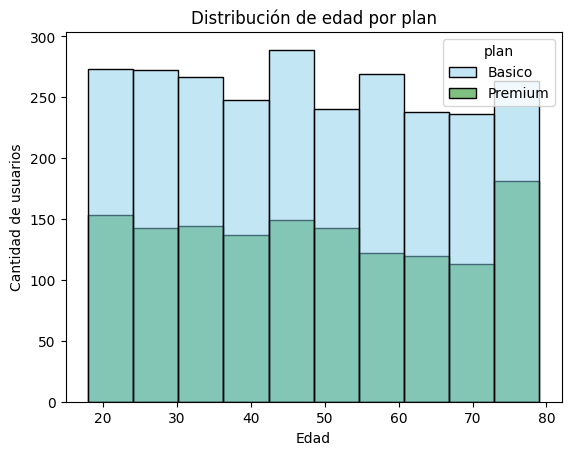

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Distribución
La cantidad total de usuarios por rango de edad se mantiene bastante estable (entre 230 y 290 usuarios por barra) evidenciando una distribicion general uniforme

💡 Insights:
• La cantidad total de usuarios por rango de edad se mantiene bastante estable (entre 230 y 290 usuarios por barra)         
• El pico más alto de usuarios totales se encuentra en el rango de 40 a 50 años (rozando los 290 usuarios).  
• En los usuarios jóvenes y adultos jóvenes (de 20 a 50 años), la contratación del plan Premium es relativamente constante, manteniéndose cerca de los 150 usuarios por rango.
• Hay una tendencia a la baja a partir de los 55 años, donde el número de usuarios Premium desciende notablemente (llegando a su punto más bajo cerca de los 70 años).
• En el grupo de mayor edad (entre 70 y 80 años), el consumo del plan Premium experimenta un aumento drástico
• El plan Básico domina claramente en los adultos mayores de entre 55 y 70 años.
    


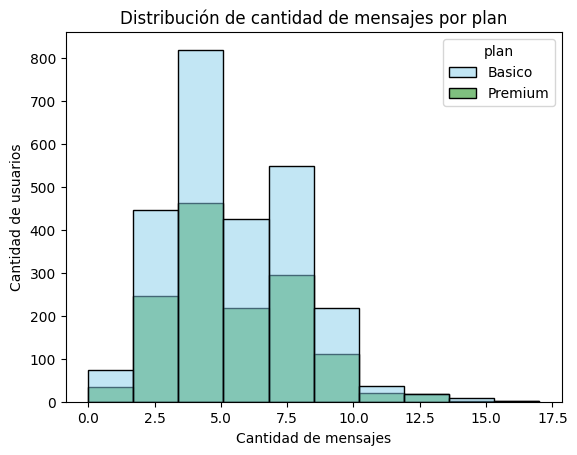

In [31]:

# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 


La distribución general presenta un claro sesgo a la derecha (sesgo positivo). La gran mayoría de los usuarios se concentra en los rangos bajos y medios de envío de mensajes (entre 25 y 75 mensajes)

El plan Básico (azul claro) concentra una cantidad masiva de usuarios en el rango de 25 a 75 mensajes. El pico absoluto de la gráfica pertenece a este plan en el intervalo de los 50 mensaje. 
El plan Premium (verde) tiene una distribución más baja en los picos, pero mantiene una presencia constante en el rango de 25 a 75 mensajes.


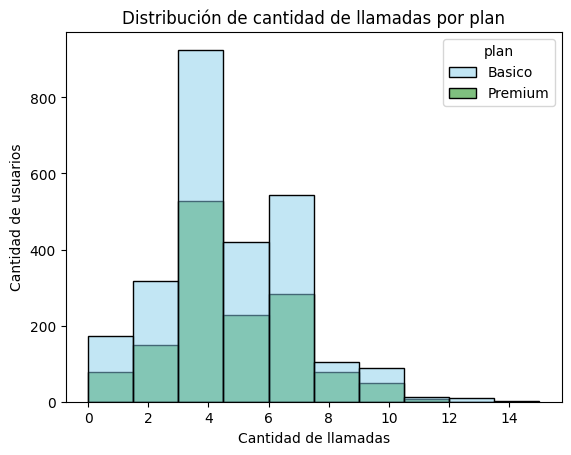

In [32]:

# Histograma para visualizar la cant_llamadas
# Cantidad de llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 

• Forma de la distribución:
La distribución general presenta un sesgo a la derecha (sesgo positivo), pero con un comportamiento bimodal (tiene dos picos notables). El pico principal y más alto (la moda absoluta) se encuentra de forma muy marcada en las 3 a 4 llamadas, seguido de un segundo pico secundario en las 6 a 7 llamadas. A partir de las 8 llamadas, la cantidad de usuarios disminuye drásticamente, casi desapareciendo después de las 12 llamadas.

• El plan Básico (azul claro) concentra su mayor volumen en los dos picos mencionados. Tiene una presencia masiva en el rango de 3 a 4 llamadas 
• El plan Premium (verde) sigue un patrón idéntico de comportamiento bimodal, pero con una proporción menor de usuarios comparado con el plan Básico. Mantiene una distribución constante en la parte central del gráfico (de 2 a 7 llamadas) y, al igual que el básico, decae fuertemente al superar las 8 llamadas.

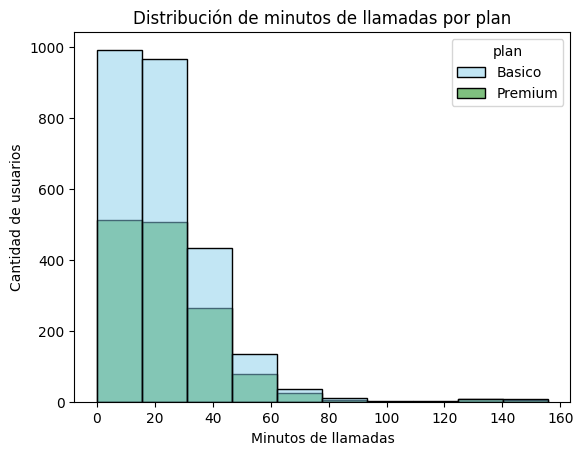

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=10,
    palette=['skyblue', 'green']
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 


La distribución general presenta un sesgo a la derecha muy pronunciado (sesgo positivo extremo). 
A partir de los 30 minutos, el uso de las llamadas cae drásticamente, creando una "cola" muy larga en la gráfica. En el rango de 0 a 30 minutos, los planes Básico (azul claro) y Premium (verde) se distribuyen de forma casi idéntica en las barras principales.
A medida que los minutos aumentan (más de 40 minutos), la cantidad de clientes en ambos grupos disminuye al mismo ritmo. Esto demuestra que el comportamiento de consumo de tiempo es muy similar entre los usuarios de ambos planes.



### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

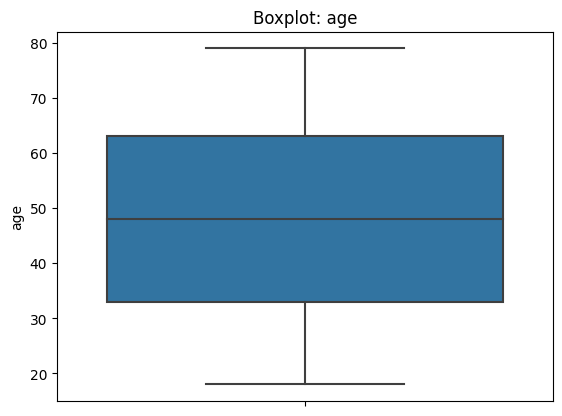

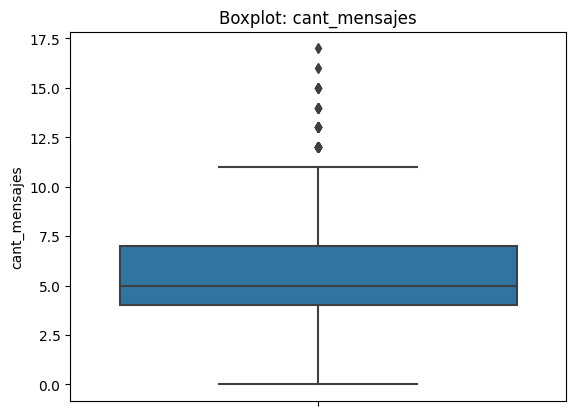

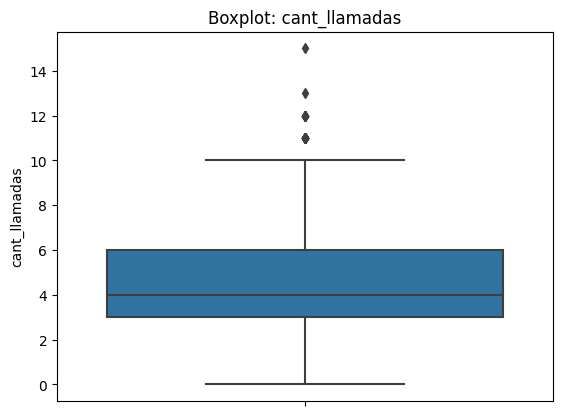

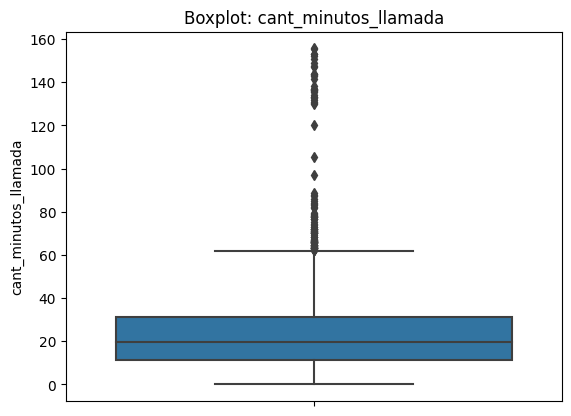

In [34]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(y=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()



💡 Insights: Edad (age)
• Forma: Es totalmente equilibrada. La mitad de los usuarios tiene menos de 48 años (mediana) y la otra mitad tiene más.
• Grupo principal: El 50% de la gente se concentra entre los 33 y 63 años.
• Datos raros: No hay datos fuera de lo común. Las edades van parecidas desde los 18 hasta los 80 años.
💡 Insights: Cantidad de mensajes (cant_mensajes)
• Forma: Está inclinada hacia los valores bajos. La mayoría de los usuarios manda unos 5 mensajes (mediana).
• Grupo principal: Lo normal es enviar entre 4 y 7 mensajes.
• Datos raros: Hay un grupo pequeño de usuarios que manda cantidades inusualmente altas, entre 12 y 17 mensajes.
💡 Insights: Cantidad de llamadas  (cant_llamadas)
• Forma: La mayoría hace pocas llamadas. El punto medio está en las 4 llamadas por usuario.
• Grupo principal: Casi todo el mundo hace entre 3 y 6 llamadas.
• Datos raros: Hay usuarios exagerados que se salen de lo normal haciendo entre 11 y 15 llamadas.
💡 Insights: Minutos de llamada  (cant_minutos_llamada)
• Forma: Está extremadamente aplastada abajo. La gran mayoría habla muy poco, con un promedio de 20 minutos (mediana).
• Grupo principal: El grueso de los usuarios consume apenas entre 10 y 31 minutos.
• Datos raros: Hay una enorme cantidad de usuarios atípicos que se alargan muchísimo, llegando a hablar desde 62 hasta más de 150 minutos.




In [35]:

# Calcular límites de outliers usando IQR

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\nColumna: {col}')
    print('Q1:', Q1)
    print('Q3:', Q3)
    print('IQR:', IQR)
    print('Límite inferior:', limite_inferior)
    print('Límite superior:', limite_superior)

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]

    print('Cantidad de outliers:', len(outliers))



Columna: age
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0
Cantidad de outliers: 0

Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5
Cantidad de outliers: 46

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5
Cantidad de outliers: 30

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575
Cantidad de outliers: 109


In [36]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
 # Definir las columnas que vamos a revisar (estaba creada columnas_numericas )
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Revisa los limites superiores y el max
#user_profile[columnas_numericas].describe()
user_profile[columnas_limites].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000



 Insights: Decisiones sobre Outliers
• cant_mensajes: Mantener.
• ¿Por qué? El máximo es 17 mensajes. Es una cantidad muy normal y real para un usuario activo, por lo que no tiene sentido borrarla.
• cant_llamadas: Mantener.
• ¿Por qué? El máximo es 15 llamadas. No es un error del sistema; refleja a personas que hablan más de la cuenta y es información útil para el negocio.
• cant_minutos_llamada: Mantener.
• ¿Por qué? El máximo son 155.69 minutos (unas 2 horas y media). Aunque la mayoría habla menos de 32 minutos, tener llamadas largas es perfectamente normal en la vida real y describe a los clientes que más consumen.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

# Verificar resultados
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10)

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso
5,10005,7.0,5.0,Uso medio
6,10006,5.0,3.0,Uso medio
7,10007,5.0,3.0,Uso medio
8,10008,5.0,5.0,Uso medio
9,10009,3.0,5.0,Uso medio


In [38]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:

# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    valores_edad,
    default='Adulto Mayor'
)
# Verificar resultados
user_profile[['user_id', 'age', 'grupo_edad']].head(10)


,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor
5,10005,61.0,Adulto Mayor
6,10006,39.0,Adulto
7,10007,70.0,Adulto Mayor
8,10008,76.0,Adulto Mayor
9,10009,47.0,Adulto


In [40]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
6.3 Visualización de la Segmentación de Clientes
🎯 Objetivo: Visualizar la distribución de los usuarios según los grupos creados: grupo_uso y grupo_edad.

Instrucciones:

Crea dos gráficos para las variables categóricas grupo_uso y grupo_edad.

Agrega título y etiquetas a los ejes en cada gráfico.

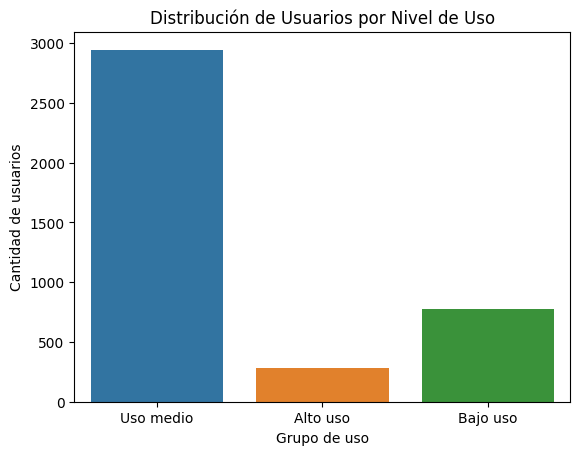

In [41]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

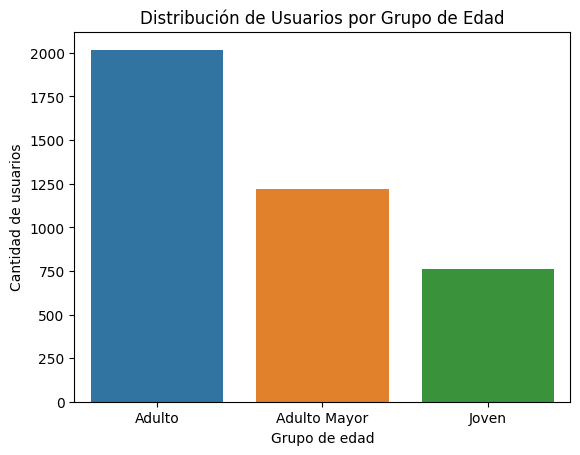

In [42]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos

•	Se encontraron valores inválidos en la columna age, específicamente el valor centinela -999, que representaba información faltante o desconocida. Estos valores fueron reemplazados utilizando la mediana de las edades válidas.
•	En la columna city se identificaron valores centinela ?, además de valores nulos. También se encontraron 40 fechas futuras en reg_date correspondientes a 2026, que fueron marcadas como valores nulos por ser inconsistentes con el periodo de análisis.
•	En usage se encontraron valores nulos importantes en duration y length, por lo que estos datos deben interpretarse con precaución antes de realizar imputaciones.

CATEGORIAS
Calidad de datos: Es importante corregir valores inválidos como -999, ?, fechas futuras y datos faltantes antes de sacar conclusiones definitivas.
Edad: La distribución es bastante equilibrada. La mayoría de los clientes está entre 30 y 59 años y no se encontraron outliers importantes después de corregir el valor -999.
Cant. de mensajes: La mayoría de clientes envía pocos mensajes. Los valores altos, hasta 17 mensajes, pueden mantenerse porque representan clientes de mayor uso.
Cant. de llamadas: La mayoría realiza pocas llamadas. Los valores de hasta 15 llamadas pueden mantenerse porque son posibles comportamientos reales de clientes con mayor consumo.
Minutos de llamada: La mayoría consume pocos minutos, pero existen clientes con consumos mucho mayores, llegando a 155.69 minutos. Estos valores pueden mantenerse porque pueden representar clientes de alto uso.
Planes: El plan Básico concentra una gran parte de los usuarios en los niveles normales de consumo, mientras que el Premium también tiene usuarios con niveles altos de actividad.

Segmentos: La combinación de edad + nivel de uso permite identificar mejor los diferentes tipos de clientes, como jóvenes, adultos o adultos mayores con bajo, medio o alto consumo.

🔍 Segmentos por Edad
•	Se identificaron tres segmentos de clientes: Joven (menores de 30 años), Adulto (de 30 a 59 años) y Adulto Mayor (60 años o más).
•	La segmentación permite comparar el comportamiento de consumo entre diferentes grupos de edad y detectar oportunidades para adaptar la oferta comercial a las necesidades de cada segmento.
•	Edad: La distribución es bastante equilibrada. La mayoría de los clientes está entre 30 y 59 años y no se encontraron outliers importantes después de corregir el valor -999.

📊 Segmentos por Nivel de Uso
•	Se clasificaron los clientes en Bajo uso, Uso medio y Alto uso, utilizando como criterios la cantidad de llamadas y mensajes realizados.
•	Los clientes de alto uso representan una oportunidad importante para ConnectaTel, ya que su mayor consumo puede estar relacionado con una mayor necesidad de servicios de comunicación y con oportunidades para ofrecer planes con mayores beneficios.
•	Cant. de mensajes: La mayoría de clientes envía pocos mensajes. Los valores altos, hasta 17 mensajes, pueden mantenerse porque representan clientes de mayor uso.
•	Cant. de llamadas: La mayoría realiza pocas llamadas. Los valores de hasta 15 llamadas pueden mantenerse porque son posibles comportamientos reales de clientes con mayor consumo.

➡️ Esto sugiere que los datos muestran que la mayoría de los clientes tiene un uso bajo o moderado, pero existe un grupo de clientes con alto consumo de llamadas y mensajes. Estos clientes no necesariamente son errores: pueden representar usuarios reales con mayores necesidades de comunicación. Por eso, es mejor analizar los outliers antes de eliminarlos y utilizar la edad y el nivel de uso para entender mejor a los clientes.

ConnectaTel puede utilizar la combinación de edad y nivel de uso para crear perfiles de clientes más precisos. Por ejemplo, un cliente joven con alto consumo puede tener necesidades diferentes a las de un adulto mayor con alto consumo. Esta segmentación permite orientar mejor las características y beneficios de los planes.

💡 Recomendaciones
•	Diseñar ofertas diferenciadas según el nivel de consumo, especialmente para clientes de alto uso, considerando mayores cantidades de minutos y mensajes u otros beneficios asociados.
•	Crear o ajustar planes dirigidos a segmentos específicos de edad y comportamiento, evitando ofrecer una única propuesta para todos los clientes.
•	Investigar los valores extremos de consumo antes de considerarlos errores, ya que algunos outliers pueden representar clientes con necesidades reales de consumo elevado.
•	Mejorar los procesos de captura y validación de datos para evitar valores centinela, fechas inconsistentes y registros incompletos en futuros análisis.
•	Utilizar periódicamente la segmentación por edad y nivel de uso para evaluar cambios en el comportamiento de los clientes y ajustar la oferta comercial.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`